Загружаем данные о рекламной компанни раннее проведеной собственником магазинов на фиолетовом маркетплейсе РФ, 
для подтверждения или опровержения ряда гепотиз и выявления закономерностей. 

Гипотезы: 
1. Тип ставки: [Ручная и Единая]  в отношении с  CR(отношение заказов к кликам)  и CPC(средняя стоимость одного клика в рублях).
Самая приоритетная — прямое практическое решение. Если ручная ставка даёт лучший CR при меньшем CPC,
это конкретная рекомендация куда перевести бюджет.

2. Затраты \ Заказы (закон убывающей отдачи)
Есть ли порог после которого каждый вложенный рубль даёт всё меньше заказов? Это напрямую влияет на решение 
об увеличении/уменьшении бюджета кампаний.

3. Кампании с показами но нулевыми заказами — есть ли паттерн
31 кампания тратят деньги и не дают заказов. Если найдём общий признак — это готовая рекомендация что отключить.

4. CPM(стоимость 1000 показов в руб.) и CR(отношение заказов к кликам)
Дорогие показы = более целевая аудитория = выше конверсия? Или деньги уходят в пустоту?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
# Загрузка данных
rek_stat = pd.read_csv(r'C:\Users\22\Desktop\Костя\Данные_чистые\rek_stat.csv', sep=';')
# Удаление дублей.
rek_stat = rek_stat.drop_duplicates(subset=['campaign_id', 'cost', 'impressions', 'clicks'])
print(f'Строк после дедупликации: {len(rek_stat)}')

Строк после дедупликации: 159


In [3]:
rek_stat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159 entries, 0 to 158
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bid_type       159 non-null    object 
 1   campaign_id    159 non-null    int64  
 2   campaign_name  159 non-null    object 
 3   started_at     159 non-null    object 
 4   finished_at    159 non-null    object 
 5   impressions    159 non-null    int64  
 6   frequency      159 non-null    float64
 7   clicks         159 non-null    int64  
 8   cpc            159 non-null    float64
 9   cpm            159 non-null    float64
 10  ctr            159 non-null    float64
 11  cr             159 non-null    float64
 12  cost           159 non-null    float64
 13  orders_qty     159 non-null    int64  
 14  added_to_cart  159 non-null    int64  
dtypes: float64(6), int64(5), object(4)
memory usage: 19.9+ KB


In [4]:
rek_stat.describe()

,campaign_id,impressions,frequency,clicks,cpc,cpm,ctr,cr,cost,orders_qty,added_to_cart
count,1.590000e+02,1.590000e+02,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,1.953635e+07,3.114651e+05,0.966101,12825.685535,13.416038,395.446289,3.531761,2.677547,78143.515157,507.421384,1698.471698
std,7.431218e+06,6.502199e+05,0.018312,26084.623124,14.330989,274.216053,2.009778,3.026664,137150.047800,1323.203910,3922.913219
min,9.953329e+06,6.000000e+00,0.860000,0.000000,0.000000,76.600000,0.000000,0.000000,3.250000,0.000000,0.000000
25%,1.103430e+07,4.293500e+03,0.960000,110.500000,5.495000,204.320000,2.410000,0.485000,1112.000000,1.000000,3.000000
50%,1.945468e+07,3.446000e+04,0.970000,1299.000000,9.380000,326.460000,3.050000,1.740000,13307.740000,18.000000,70.000000
75%,2.567596e+07,2.919885e+05,0.980000,14367.500000,15.675000,462.465000,4.390000,3.785000,87692.190000,225.000000,1228.500000
max,3.631189e+07,4.473194e+06,1.000000,190748.000000,120.720000,1444.970000,16.350000,14.290000,754155.360000,7924.000000,21871.000000


In [5]:
rek_stat.isna().sum()

bid_type         0
campaign_id      0
campaign_name    0
started_at       0
finished_at      0
impressions      0
frequency        0
clicks           0
cpc              0
cpm              0
ctr              0
cr               0
cost             0
orders_qty       0
added_to_cart    0
dtype: int64

In [6]:
rek_stat.head(5)

,bid_type,campaign_id,campaign_name,started_at,finished_at,impressions,frequency,clicks,cpc,cpm,ctr,cr,cost,orders_qty,added_to_cart
0,Единая Ставка,15362355,133763577 ✅ коровка 15.03.2024,2024-03-15 18:59:47,2024-04-13 23:59:59,129177,0.97,4113,8.30,264.15,3.18,1.29,34123.15,53,471
1,Единая Ставка,10588593,707 автоКампания,2023-10-08 23:25:25,2023-10-12 19:54:05,4431,0.98,111,36.17,906.20,2.51,0.90,4015.41,1,1
2,Ручная Ставка,33414520,Новая Ручная Черная ДР от 28.01.2026,2026-01-28 14:09:29,2026-05-07 13:39:50,415961,0.96,18097,6.74,293.21,4.35,7.84,121964.82,1418,4284
3,Единая Ставка,29187155,Единая полки Черная ДР от 06.10.2025,2025-10-06 14:08:38,2025-10-06 20:19:08,8169,0.97,262,4.23,135.58,3.21,6.49,1107.59,17,46
4,Единая Ставка,21404267,Арк новый тест от 15.11.2024,2024-11-15 13:00:39,2024-11-15 23:59:59,356,0.97,10,12.82,360.14,2.81,0.00,128.21,0,1


-------------------------------------------------------------------------------------------------------------------------------------------------------

ГИПОТЕЗА  № 1.  \
Рассмотрим гипотезу о том, какая ставка в рекламной комании и в каких конкретных 
случаях является наиболее эффективной. Виды сатвок: [Ручная и Единая]


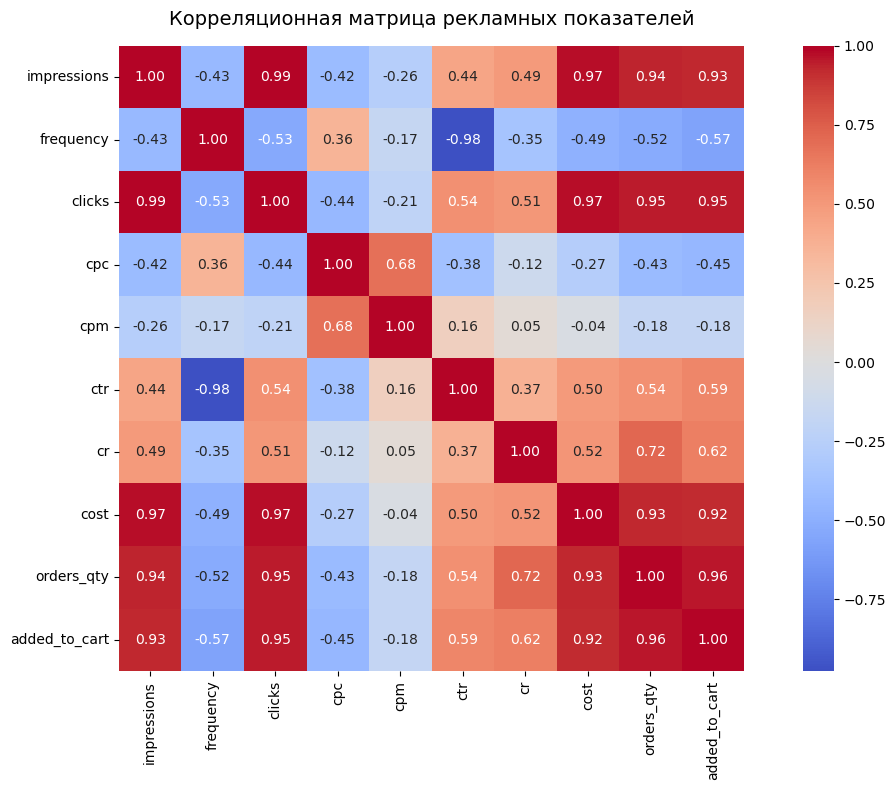

In [7]:
# Шаг 1 - Корреляционная матрица
numeric_cols = ['impressions', 'frequency', 'clicks', 'cpc', 'cpm', 'ctr', 'cr', 'cost', \
                'orders_qty', 'added_to_cart']

# Считаем корреляцию методом Спирмена т.к. наши даные распределены не нормальным образом
# есть выбросы CPC max 120 при среднем 13.
corr_matrix = rek_stat[numeric_cols].corr(method='spearman')

# Визуализируем в виде тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # показывать цифры внутри ячеек
    fmt='.2f',         # до 2 знаков после заяпятой
    cmap='coolwarm',   # синий = отриц. корреляция, красный = положит.
    center=0,          # Белый цыет = 0
    square=True        # задаем форму ячеек, как строго квадратную
)
plt.title('Корреляционная матрица рекламных показателей', fontsize=14,  pad=15) # размер шрифта / отступ 
plt.tight_layout() # автоматической настройки/коррекция полей 
plt.show()

In [8]:
# Смотрим по отдельности на кампании каждого типа и базовую статистику
print(rek_stat['bid_type'].value_counts())
print()
display(rek_stat.groupby('bid_type')[['cr', 'cpc', 'cost', 'orders_qty']].median())

bid_type
Единая Ставка    106
Ручная Ставка     53
Name: count, dtype: int64



,cr,cpc,cost,orders_qty
bid_type,,,,
Единая Ставка,0.905,8.365,7237.935,9.5
Ручная Ставка,3.600,10.360,40585.040,83.0


Промежуточные выводы: 

(При медианных показателях удалось выяснить что...)
Ручная ставка даёт CR в 4 раза выше (3.6 vs 0.9)
Заказов в 9 раз больше (83 vs 9.5)
Но CPC дороже на 24% (10.36 vs 8.37)
И затраты в 6 раз выше (40585 vs 7238)

Медианные затраты у ручной ставки в 6 раз больше. Это значит что мы сравниваем кампании 
с разным бюджетом. Естественно что при бюджете в 40к заказов больше чем при 7к — это
не заслуга типа ставки, а просто масштаб. 

Поэтому прежде чем делать финальный вывод нужно сделать две вещи:
1. Нормализовать — смотреть не на абсолютные заказы, а на заказы на рубль затрат
(эффективность рубля).
2. Провести статистический тест — убедиться что разница в CR не случайная.

In [9]:
# Считаем заказы на 1000 рублей затрат
rek_stat['orders_per_1k'] = (rek_stat['orders_qty'] / rek_stat['cost']) * 1000
# Смотрим медиану по этому показателю
print(rek_stat.groupby('bid_type')[['cr', 'cpc', 'orders_per_1k']].median())
print()

# Разделяем две группы для теста
group_single = rek_stat[rek_stat['bid_type'] == 'Единая Ставка'] ['cr']
group_manual = rek_stat[rek_stat['bid_type'] == 'Ручная Ставка'] ['cr']

# Тест Манна-Уитни - првоеряем статистически значима ли разница CR
# Используем его, а не t-тест потому что данные скорее всего не нормально распределены
stat, p_value = stats.mannwhitneyu(group_single, group_manual, alternative='two-sided')
print(f'[-value: {p_value:.4f}')
print('Разница статистически значима' if p_value < 0.05 else 'Разница случайная')

                  cr     cpc  orders_per_1k
bid_type                                   
Единая Ставка  0.905   8.365       1.113097
Ручная Ставка  3.600  10.360       3.332334

[-value: 0.0000
Разница статистически значима


Вывод: \
'Ручная' ставка статистически значимо эффективнее 'Единой' по всем ключемым показателям. \
CR выше в 4 раза, эффективность каждого вложенного рубля в 3 раза выше, не смотря на то, что CPC дороже на 24% - каждый вложенный рубль возвращает втрое больше заказов. \
Рекомендация: пересмотреть кампании на "Единой" ставке в пользу "Ручного" управления. 

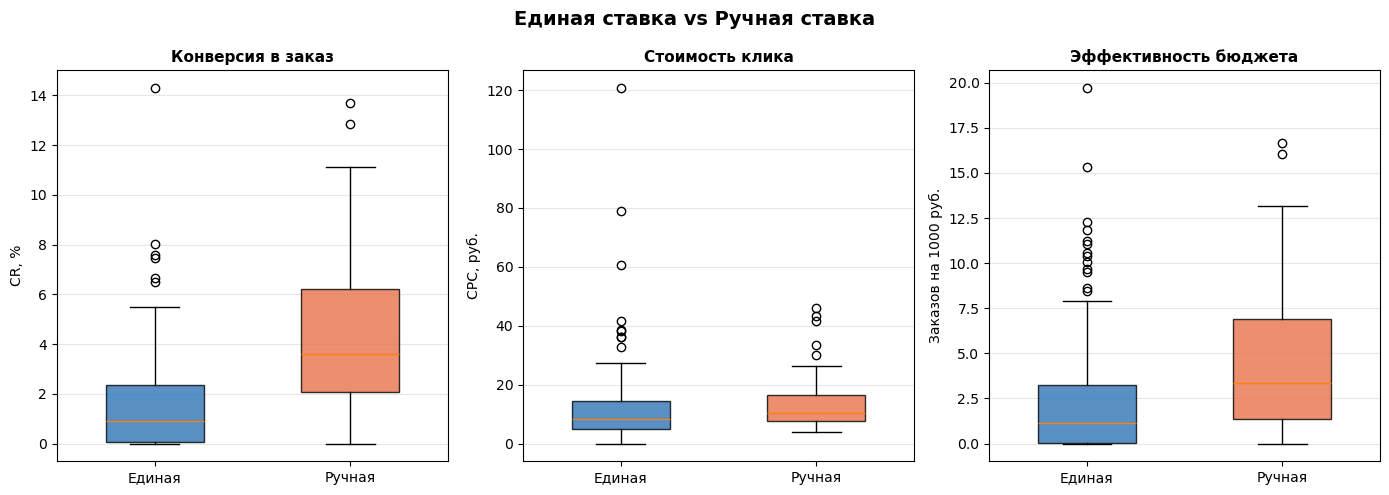

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))  # создает сетку из 1 строки и 3 колонок
fig.suptitle('Единая ставка vs Ручная ставка', fontsize=14, fontweight='bold') # заголовок

# Настройка данных
metrics = [
    ('cr',            'CR, %',                    'Конверсия в заказ'),
    ('cpc',           'CPC, руб.',                'Стоимость клика'),
    ('orders_per_1k', 'Заказов на 1000 руб.',     'Эффективность бюджета'),
]

colors = ['#2E75B6', '#E8734A']

for ax, (col, ylabel, title) in zip(axes, metrics):
    data = [
        rek_stat[rek_stat['bid_type'] == 'Единая Ставка'][col],
        rek_stat[rek_stat['bid_type'] == 'Ручная Ставка'][col],
    ]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Единая', 'Ручная'])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Конверсия в заказ (CR) — ящик ручной ставки (оранжевый) заметно выше и шире. Медиана выше, и разброс больше — ручные кампании либо работают очень хорошо, либо очень плохо. Единая ставка стабильнее но стабильно слабее.

Стоимость клика (CPC) — ящики почти на одном уровне, разница небольшая. Это подтверждает цифры — всего 24% разницы. Выбросы есть у обоих типов.

Эффективность бюджета — картина аналогична CR. Ручная ставка даёт больше заказов на рубль, но с большим разбросом.

-------------------------------------------------------------------------------------------------------------------------------------------------------

ГИПОТЕЗА № 2. /
Закон убывающей отдачи \
Идея такая: при малом бюджете каждый вложенный рубль даёт много заказов, 
но после определённого порога отдача начинает падать. То есть удвоение 
бюджета не даёт удвоения заказов.


In [11]:
# Убираем выбросы по затратам чтобы они не искажали каритину
# Оставляем только кампании в пределах 95-го перцентиля
cost_95 = rek_stat['cost'].quantile(0.95)
df_filtered = rek_stat[rek_stat['cost'] <= cost_95].copy()

print(f'Убрали выбросы выше {cost_95:.0f} руб.')
print(f'Осталось строк: {len(df_filtered)} из {len(rek_stat)}')
print()

# Делим кампанни на 4 группы по размеру бюджета
df_filtered['cost_group'] = pd.qcut(
    df_filtered['cost'],
    q=4,
    labels=['Низкий', 'Средний', 'Высокий', 'Очень высокий']
)
# Эффективность каждой группы
print(df_filtered.groupby('cost_group', observed=True)[['cost', 'orders_qty', \
     'orders_per_1k', 'cr']].median())

Убрали выбросы выше 424234 руб.
Осталось строк: 151 из 159

                     cost  orders_qty  orders_per_1k     cr
cost_group                                                 
Низкий            309.425         0.0       0.000000  0.000
Средний          3262.480         3.0       1.206798  1.085
Высокий         29748.430       101.0       3.949531  2.720
Очень высокий  142691.970       598.5       5.267489  2.395


Промежуточные выводы: \
от низкого к высокому бюджету эффективность растёт - это противоречит классическому 
убывающей отдачи. Но между "Высокий" и "Очень высокий" рост почти останавливается: \ 
3.9 и 5.3 зказов на каждую потраченную тысячу, тогда как бюджет вырос в 5 раз. \
А CR даже падает на самом высоком бюджете (с 2.7 до 2.4) — вот здесь закон 
убывающей отдачи и начинает работать. \
То есть порог примерно ~30 000 руб. — после него каждый дополнительный рубль даёт всё меньше отдачи.

In [12]:
# Смотрим сколько кампаний с нулевыми заказами в каждой группе
zero_orders = df_filtered.groupby('cost_group', observed=True).apply(
      lambda x: (x['orders_qty'] == 0).sum(), include_groups=False
).reset_index()
zero_orders.columns = ['cost_group', 'нулевые_заказы']
zero_orders['всего'] = df_filtered.groupby('cost_group', observed=True).size().values
zero_orders['доля_%'] = (zero_orders['нулевые_заказы'] / zero_orders['всего'] * 100).round(1)
print(zero_orders)

      cost_group  нулевые_заказы  всего  доля_%
0         Низкий              29     38    76.3
1        Средний               1     38     2.6
2        Высокий               1     37     2.7
3  Очень высокий               0     38     0.0


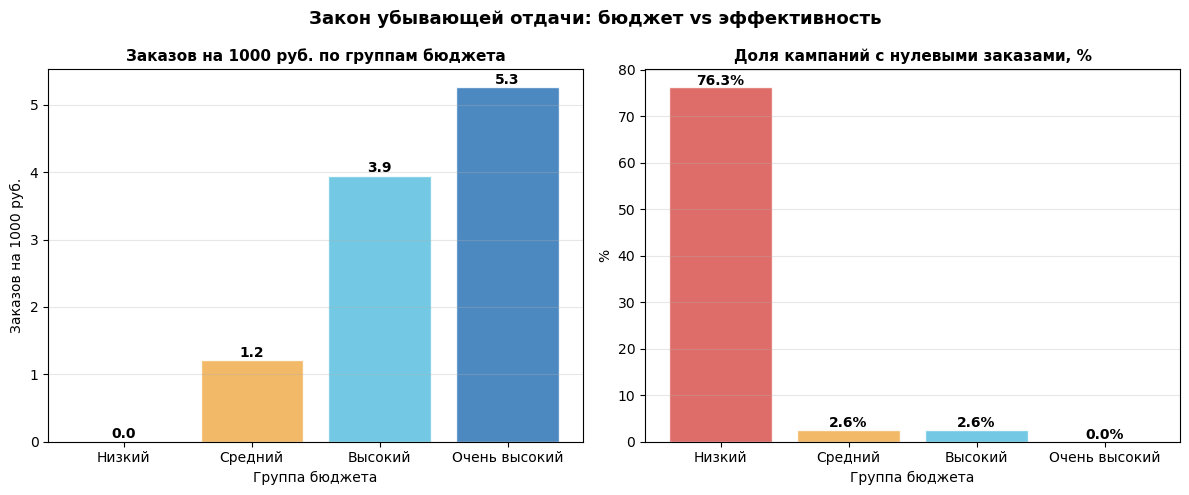

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Закон убывающей отдачи: бюджет vs эффективность', 
             fontsize=13, fontweight='bold')

# График 1 — эффективность бюджета по группам
groups = ['Низкий', 'Средний', 'Высокий', 'Очень высокий']
efficiency = df_filtered.groupby('cost_group', observed=True)['orders_per_1k'].median()
colors_bar = ['#d9534f', '#f0ad4e', '#5bc0de', '#2E75B6']

axes[0].bar(groups, efficiency, color=colors_bar, alpha=0.85, edgecolor='white')
axes[0].set_title('Заказов на 1000 руб. по группам бюджета', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Заказов на 1000 руб.')
axes[0].set_xlabel('Группа бюджета')
for i, v in enumerate(efficiency):
    axes[0].text(i, v + 0.05, f'{v:.1f}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# График 2 — доля кампаний с нулевыми заказами
zero_pct = [76.3, 2.6, 2.6, 0.0]
axes[1].bar(groups, zero_pct, color=colors_bar, alpha=0.85, edgecolor='white')
axes[1].set_title('Доля кампаний с нулевыми заказами, %', fontsize=11, fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xlabel('Группа бюджета')
for i, v in enumerate(zero_pct):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

ГИПОТЕЗА № 2. \
Вывод: \
Гипотеза подтверждена частично — закон убывающей отдачи проявляется при бюджете свыше 30 000 руб.
Кампании с бюджетом до ~1000 руб. (76% нулевых заказов) являются тестовыми и исключены из оценки 
закона убывающей отдачи. Среди рабочих кампаний (бюджет от ~3000 руб.) эффективность растёт до 
порога ~30 000 руб., после которого прирост замедляется — бюджет растёт вплость до 5-ти раз, а эффективность уже только на 25%. 
Даже замедленный рост — это всё же рост. 
Если бюджет вырос в 5 раз и дал +25% эффективности — это значит что абсолютное количество заказов всё равно сильно выросло. Просто каждый дополнительный рубль стал чуть менее ценным, но не убыточным.

-------------------------------------------------------------------------------------------------------------------------------------------------------

ГИПОТЕЗА № 3. \
Кампании с показами но нулевыми заказами — есть ли паттерн
31 кампания тратит деньги и не дают заказов. Если найдём общий признак — это готовая рекомендация что отключить.

In [14]:
# Выделяем кампании с показами но нулевыми заказами
df_zero = rek_stat[(rek_stat['orders_qty'] == 0) & (rek_stat['impressions'] > 0)].copy()

print(f'Кампаний с нулевыми заказами: {len(df_zero)}')
print()

# Смотрим по типу ставки
print('По типу ставки:')
print(df_zero['bid_type'].value_counts())
print()

# Смотрим базовые метрики
print('Медианные показатели:')
print(df_zero[['cost', 'impressions', 'clicks', 'ctr', 'cr']].median())
print()

# Сравниваем с остальными кампаниями
df_nonzero = rek_stat[rek_stat['orders_qty'] > 0]
print('Медианный бюджет — нулевые заказы:', df_zero['cost'].median())
print('Медианный бюджет — есть заказы:', df_nonzero['cost'].median())

Кампаний с нулевыми заказами: 31

По типу ставки:
bid_type
Единая Ставка    27
Ручная Ставка     4
Name: count, dtype: int64

Медианные показатели:
cost           134.82
impressions    562.00
clicks          10.00
ctr              2.15
cr               0.00
dtype: float64

Медианный бюджет — нулевые заказы: 134.82
Медианный бюджет — есть заказы: 29862.265


In [15]:
# Есть ли среди нулевых кампании с нормальным бюджетом
# которые всё равно не дают заказов — вот это было бы интересно
print('Нулевые кампании с бюджетом > 5000 руб:')
df_zero_rich = df_zero[df_zero['cost'] > 5000]
print(f'Таких: {len(df_zero_rich)}')
print()
if len(df_zero_rich) > 0:
    print(df_zero_rich[['campaign_name', 'bid_type', 'cost', 
                          'impressions', 'clicks', 'ctr']].to_string())

Нулевые кампании с бюджетом > 5000 руб:
Таких: 1

                               campaign_name       bid_type      cost  impressions  clicks   ctr
116  ! АвтотКампания Сингапур  от 05.10.2023  Единая Ставка  13339.53        19877     407  2.05


ГИПОТЕЗА № 3. \
Вывод: \
Гипотеза закрыта: паттерн найден, системной проблемы нет, 
выявлена одна точечная аномалия требующая внимания.
Из 159 кампаний 31 имеет показы, но нулевые заказы. На первый взгляд — тревожный 
сигнал, но анализ показал что паттерн однозначный: 87% таких кампаний (27 из 31) 
это единая ставка с медианным бюджетом 135 руб. против 29 862 руб. у рабочих кампаний. 
Разница в 220 раз. Это вероятно тестовые запуски — првоерка реакции аудитории перед 
возможным масштабированием. Паттерн ожидаемый и осознанный.
Исключение — "Автокампания Сингапур от 05.10.2023": бюджет 13 339 руб., 19 877 показов, 
407 кликов с CTR 2.05% — и ноль заказов. Люди видят рекламу, кликают, но не покупают. 
Это сигнал проблемы не в рекламе, а в самой карточке товара — вероятно слабые фото, 
описание или цена не конкурентна. 

-------------------------------------------------------------------------------------------------------------------------------------------------------

ГИПОТЕЗА № 4. \
CPM(стоимость 1000 показов в руб.) и CR(отношение заказов к кликам) \
Дорогие показы = более целевая аудитория = выше конверсия? Или деньги уходят в пустоту? \
Гипотеза закрыта и оправергнута ещё при работе над первой гипотизой была составленна корреляционна матрица в которой было обнаруженно, что  корреляция cpm и cr (0.05) — почти ноль. Дорогие показы никак не связаны с конверсией!

-------------------------------------------------------------------------------------------------------------------------------------------------------